# Computing Fiber Diffraction Patterns

Tilt: 0 , Rotation: 0
Tilt: 0 , Rotation: 5
Tilt: 0 , Rotation: 10
Tilt: 0 , Rotation: 15
Tilt: 0 , Rotation: 20
Tilt: 0 , Rotation: 25
Tilt: 0 , Rotation: 30
Tilt: 0 , Rotation: 35
Tilt: 0 , Rotation: 40
Tilt: 0 , Rotation: 45
Tilt: 0 , Rotation: 50
Tilt: 0 , Rotation: 55
Tilt: 0 , Rotation: 60
Tilt: 0 , Rotation: 65
Tilt: 0 , Rotation: 70
Tilt: 0 , Rotation: 75
Tilt: 0 , Rotation: 80
Tilt: 0 , Rotation: 85
Tilt: 0 , Rotation: 90
Tilt: 0 , Rotation: 95
Tilt: 0 , Rotation: 100
Tilt: 0 , Rotation: 105
Tilt: 0 , Rotation: 110
Tilt: 0 , Rotation: 115
Tilt: 0 , Rotation: 120
Tilt: 0 , Rotation: 125
Tilt: 0 , Rotation: 130
Tilt: 0 , Rotation: 135
Tilt: 0 , Rotation: 140
Tilt: 0 , Rotation: 145
Tilt: 0 , Rotation: 150
Tilt: 0 , Rotation: 155
Tilt: 0 , Rotation: 160
Tilt: 0 , Rotation: 165
Tilt: 0 , Rotation: 170
Tilt: 0 , Rotation: 175
Tilt: 0 , Rotation: 180


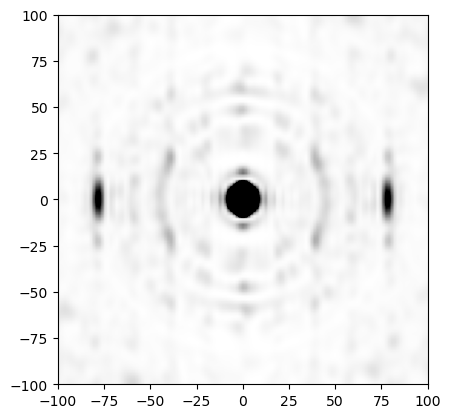

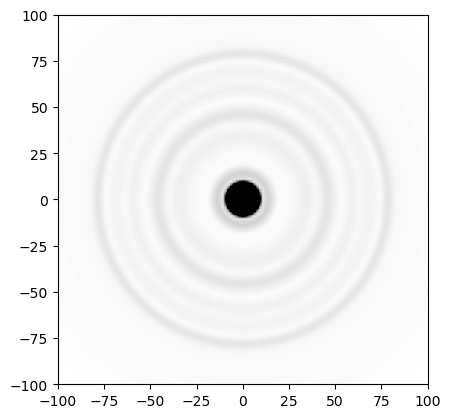

In [4]:
from scriptspowder1 import *

# An xyz file containing the atomic coordinates
# Hydrogen atoms do not need to be included in the xyz file
# In this example, we provide the coordinates of one triaminopyrimidine 
# and cyanuric acid with a 6-carbon chiral tail hexad unit

# Other available examples are 'geometries/TAP_CyCo6.xyz' and 'geometries/TAP_Cy.xyz'

coordinates_file = 'HexaplexWithCOO.xyz'

# Specify the rise, twist, and number of hexad units in the stack
#rise = 3.4 # Angstroms
#twist = 30 # Degrees
#number_of_hexads = 50
#output_coordinate = 'fiber.xyz' # Save the generated geometry to this file

# Specify the tilt and rotation series
tilts = [0] # Degrees. The rotation of the whole fiber with respect to the incoming light beam
rotations = range(0, 181, 5) # Degrees. The rotation of the whole fiber around its axis (0 to 180 inclusive)

# Specify the fiber diffraction parameters
wavelength = 0.7749e-7 # The wavelength of the light beam in mm
distance_to_detector = 338.4 # The y-axis distance to the detector in mm
z_grid_limits = [-100.0, 100.0] # The limits of the grid along the z-axis in mm
x_grid_limits = [-100.0, 100.0] # The limits of the grid along the x-axis in mm
z_grid_size = 129*1 # The resolution of the grid along the z-axis
x_grid_size = 129*1 # The resolution of the grid along the x-axis
max_intensity_scaling = 0.01 # A scale factor to limit the maximum intensity in the diffraction plot

# Read the atomic coordinates
coords = np.loadtxt(coordinates_file, usecols=(1, 2, 3), skiprows=2)
atoms = np.loadtxt(coordinates_file, usecols=(0,), skiprows=2, dtype='str')

# Make a hexad helix; comment out if not using a hexad system
#atoms, coords = helix_maker(atoms, coords, rise, twist, number_of_hexads)
#save_xyz(atoms, coords, output_coordinate)

# Update coordinates and atomic numbers
coords *= 1e-7 # Convert from Angstroms to mm
atomic_numbers = [atomic_number[a] for a in atoms] # Convert from elements to atomic numbers

# Initialize diffraction data
diffraction_data = np.zeros((z_grid_size, x_grid_size))

# Obtain diffraction data for a tilt series
for tilt in tilts:
    # Apply the beam tilt (rotation about y) to the original coordinates
    tilted_coords = np.dot(Ry(tilt), coords.T).T

    # Obtain diffraction data for a rotation series
    for rotation in rotations:
        print("Tilt:", tilt, ', Rotation:', rotation)
        # Rotate the tilted coordinates about the fiber axis (z). Each rotation is applied
        # to the tilted originals, so the rotations do not accumulate.
        current_coords = np.dot(Rz(rotation), tilted_coords.T).T

        # Generate the fiber diffraction. The per-orientation call is vectorized over the
        # detector grid and runs across all CPU cores; here we simply sum the individual
        # diffraction patterns over the tilt-rotation series.
        diffraction_data += generate_fiber_diffraction(atomic_numbers, current_coords, wavelength, distance_to_detector, 
                                                       z_grid_limits, x_grid_limits, z_grid_size, x_grid_size)

# Plot the fiber diffraction pattern
plot_fiber_diffraction(diffraction_data, z_grid_limits, x_grid_limits, max_intensity_scaling)

# Plot the powder diffraction pattern
plot_powder_diffraction(diffraction_data, z_grid_limits, x_grid_limits, max_intensity_scaling)